# 4주차_데이터 탐색과 시각화 Ⅰ

- 시간 시각화

---

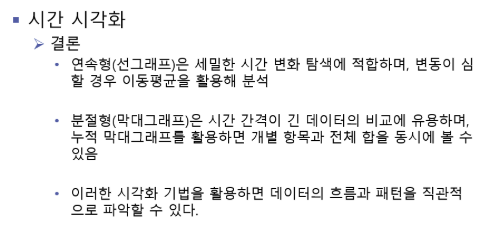

In [1]:
# 필요한 패키지 설치

import matplotlib.pyplot as plt
import pandas as pd
import datetime
plt.rcParams['figure.dpi'] = 300

In [3]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting
df = pd.read_csv("../../main/datasets/superstore.csv")

# 데이터 샘플 확인
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# 날짜 변환 (일/월/연도 형식으로 변환)
df['Date2'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
# 'Order Date' 컬럼을 datetime 형식으로 변환하여 'Date2'라는 새 컬럼에 저장함
# dayfirst=True 옵션은 날짜 형식을 '일/월/연도' 순으로 해석하게 함 (예: 25/12/2018)
# errors='coerce'는 변환이 불가능한 잘못된 형식의 날짜는 NaT(Not a Time)으로 처리함

# 날짜 오름차순 정렬
df = df.sort_values(by='Date2')
# 'Date2' 컬럼을 기준으로 데이터프레임을 오름차순 정렬함
# 시간 순서에 따른 시계열 분석을 위해 필요한 정렬 과정임

# 연도 컬럼 생성
df['Year'] = df['Date2'].dt.year
# datetime 형식의 'Date2'에서 연도(year)만 추출하여 'Year'라는 새 컬럼을 생성함
# 연도별 필터링 또는 집계를 위한 전처리 작업임

# 2018년 데이터만 필터링
df_line = df[df.Year == 2018]
# 'Year' 컬럼이 2018인 행만 필터링하여 df_line이라는 새 데이터프레임에 저장함
# 특정 연도의 추세 분석이나 매출 집계를 위한 데이터 추출 과정임

# 일자별 매출 합계
df_line = df_line.groupby('Date2')['Sales'].sum().reset_index()
# 'Date2'를 기준으로 그룹화하여 해당 날짜의 'Sales' 합계를 계산함
# reset_index()를 통해 결과를 다시 일반적인 데이터프레임 형식으로 변환함
# 일자별 매출 추세 분석을 위한 시계열 집계 결과임

# 확인
df_line.head()
# df_line 데이터프레임의 상위 5개 행을 출력하여 집계 결과를 확인함
# 날짜별로 매출이 올바르게 합산되었는지 확인하는 디버깅 과정임


,Date2,Sales
0,2018-01-01,1481.828
1,2018-01-02,2079.554
2,2018-01-03,2070.272
3,2018-01-06,33.740
4,2018-01-07,3395.590


In [5]:
df['Date2']

7980   2015-01-03
741    2015-01-04
740    2015-01-04
739    2015-01-04
1759   2015-01-05
          ...    
1297   2018-12-30
906    2018-12-30
645    2018-12-30
908    2018-12-30
5091   2018-12-30
Name: Date2, Length: 9800, dtype: datetime64[ns]

<Axes: xlabel='Date2'>

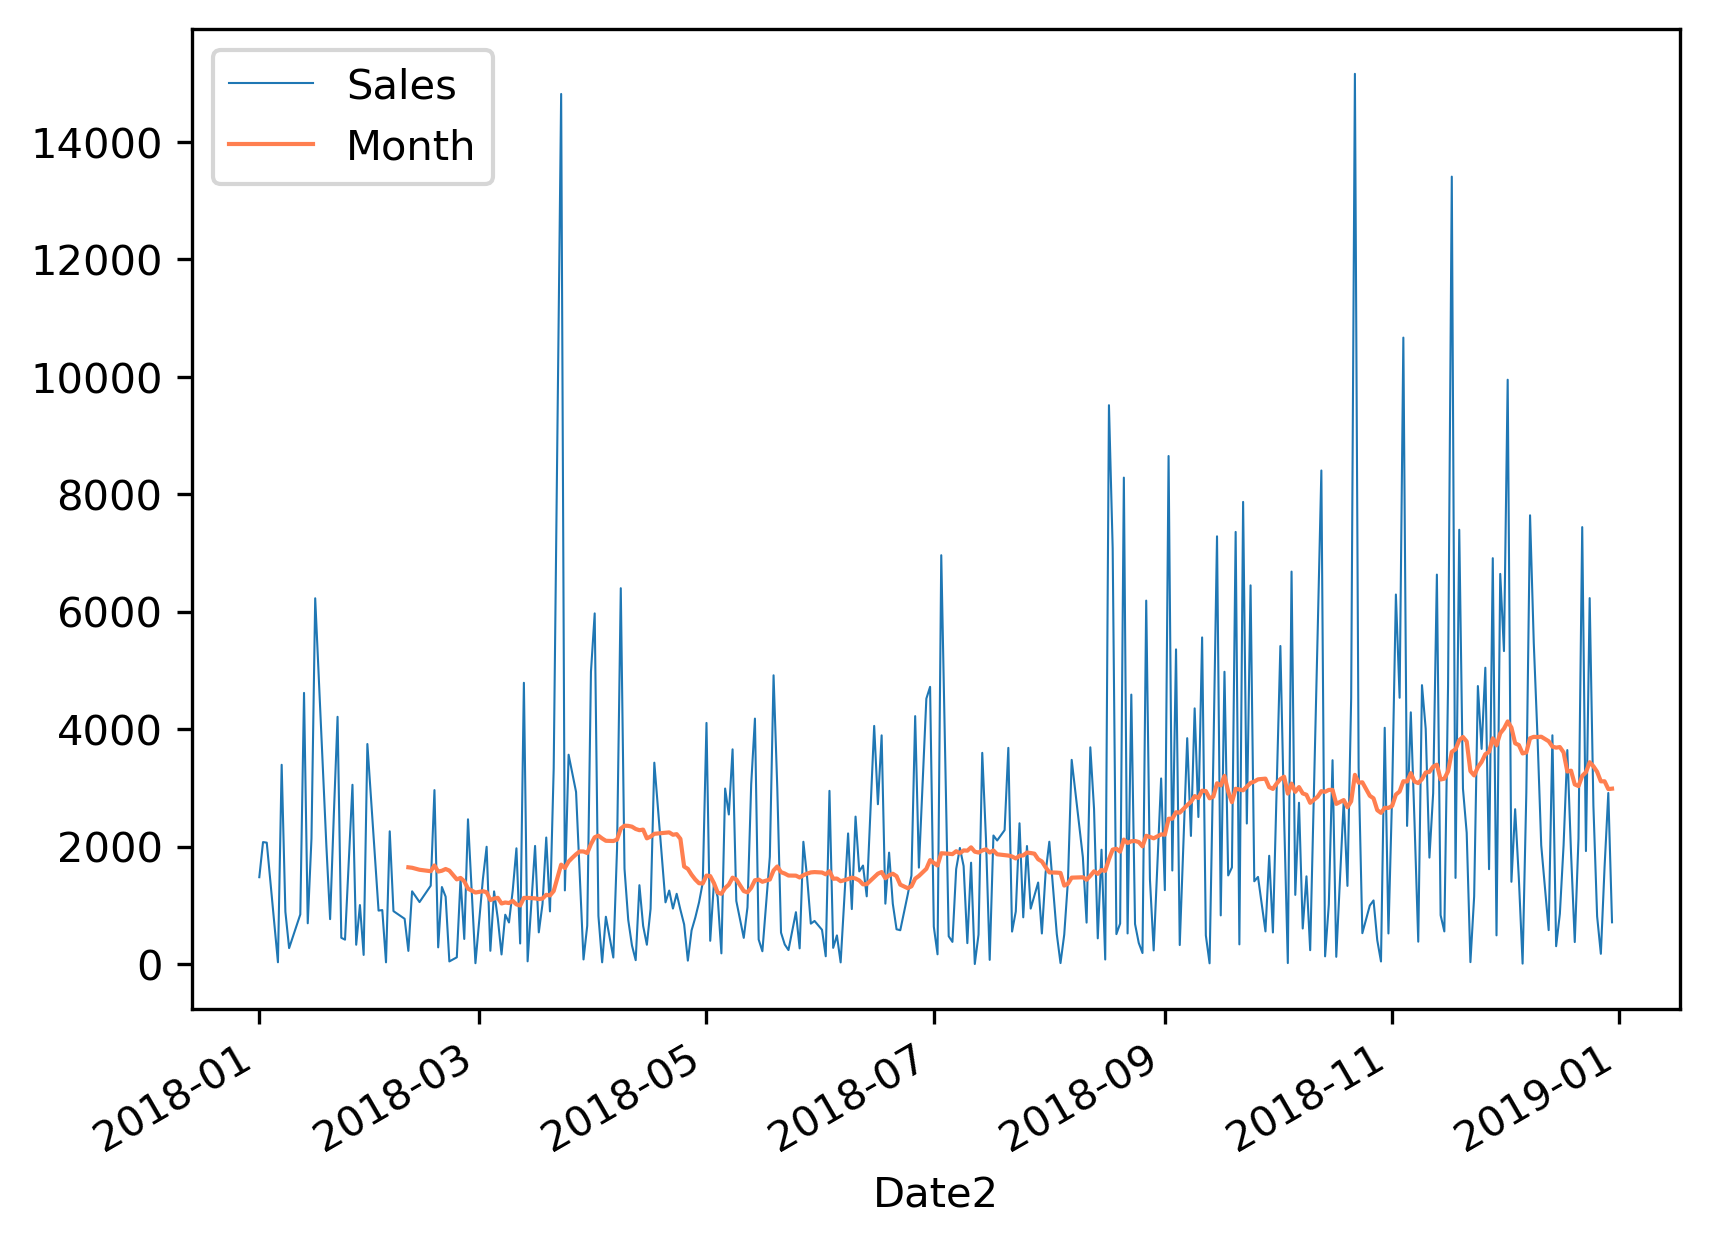

In [6]:
# 30일 이동평균 생성
df_line['Month'] = df_line['Sales'].rolling(window=30).mean()
# 'Sales' 컬럼에 대해 30일 기준의 이동평균을 계산하여 'Month'라는 새 컬럼에 저장함
# 이동평균은 단기 변동성을 완화하고 추세(trend)를 파악하는 데 유용함
# window=30은 직전 30일간의 매출 평균을 현재 날짜에 대응시킴

# 선 그래프 시각화
ax = df_line.plot(x='Date2', y='Sales', linewidth="0.5")
# x축은 날짜(Date2), y축은 일별 매출(Sales)을 선 그래프로 시각화함
# linewidth="0.5"로 선 두께를 얇게 설정하여 세밀한 일별 변동을 표현함
# 반환된 matplotlib axes 객체를 ax에 저장하여 이후 그래프에 재활용함

df_line.plot(x='Date2', y='Month', color='#FF7F50', linewidth="1", ax=ax)
# 동일한 x축(Date2)을 기준으로 'Month'(30일 이동평균) 컬럼을 같은 그래프(ax)에 겹쳐서 시각화함
# 원래의 매출 그래프 위에 트렌드선(이동평균선)을 강조하여 추가함
# color='#FF7F50'(코랄 색상)으로 설정하여 시각적으로 트렌드선을 돋보이게 표현함
# linewidth="1"로 선을 원래보다 두껍게 설정하여 이동평균선임을 명확히 함


In [ ]:
# 연도 별 판매량 데이터 가공
df_bar_1 = df.groupby('Year')['Sales'].sum().reset_index()
# 'Year' 컬럼을 기준으로 그룹화하여 연도별 'Sales' 총합을 계산함
# reset_index()를 통해 그룹화 결과를 일반적인 데이터프레임 형태로 변환함
# 연도별 총 매출 추세를 파악하거나 바 차트 등으로 시각화하기 위한 집계 작업임

df_bar_1.head()
# 연도별 총 매출이 계산된 df_bar_1 데이터프레임의 상위 5개 행을 출력함
# 데이터가 정상적으로 집계되었는지 확인하는 과정임

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


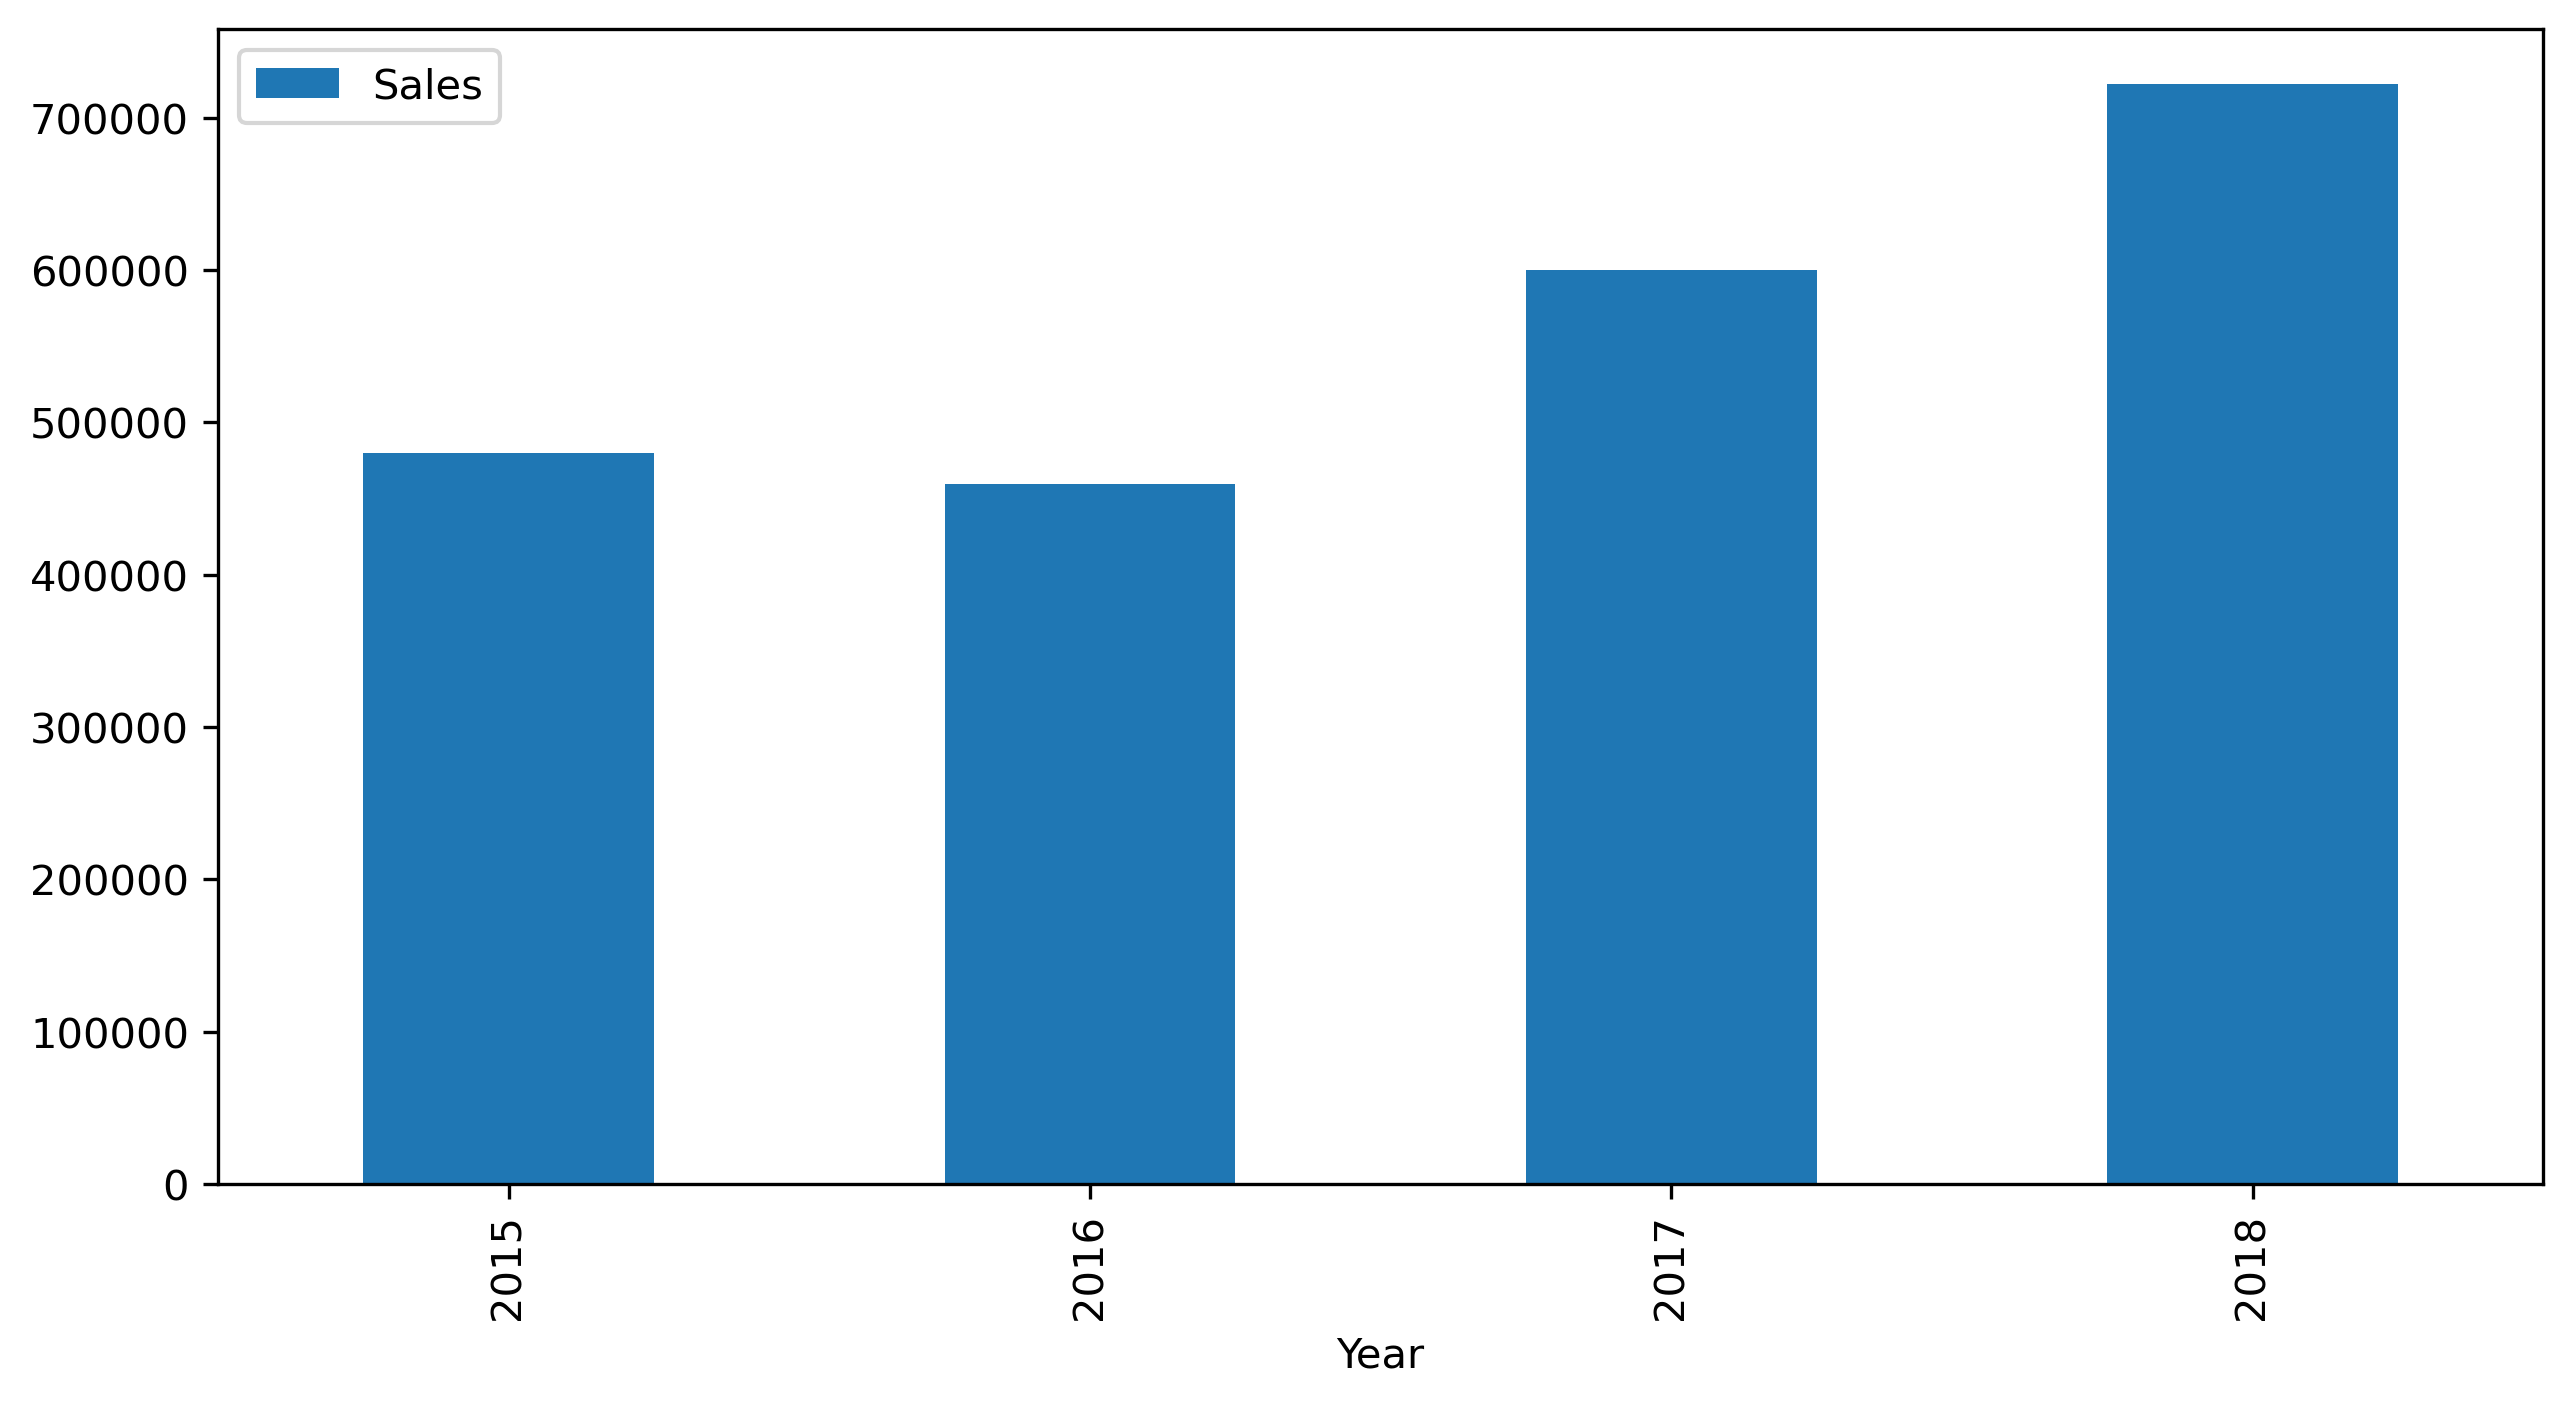

In [9]:
# 연도 별 매출액 막대 그래프 시각화
ax = df_bar_1.plot.bar(x='Year', y='Sales', rot=90, figsize=(10,5))
# df_bar_1 데이터프레임을 사용하여 연도(Year)를 x축, 매출액(Sales)을 y축으로 하는 막대 그래프를 생성함
# rot=90은 x축의 연도 라벨을 90도 회전시켜 가독성을 높임
# figsize=(10,5)는 그래프의 가로/세로 크기를 설정하여 출력 시 레이아웃이 깨지지 않도록 조정함
# 반환된 matplotlib의 axes 객체를 ax에 저장함으로써 이후 커스터마이징에 활용 가능함 (예: 제목 추가, 스타일 조정 등)

In [22]:
# 연도별, 고객 세그먼트 별 매출액 데이터 가공
df_bar_2 = df.groupby(['Year', 'Segment'])['Sales'].sum().reset_index()
# 'Year'와 'Segment'를 기준으로 그룹화하여, 각 연도와 고객 세그먼트 조합별 매출 합계를 계산함
# reset_index()를 통해 결과를 일반적인 데이터프레임 형태로 변환함
# 다양한 고객군의 연도별 기여도를 비교하거나 시각화하기 위한 다차원 집계 작업임
# 👉 이 df_bar_2는 (최대 16, 3) 형태일 것.
# 하지만 특정 조합(Year + Segment)에 데이터가 없는 경우에는 16개가 안 될 수 있음.

# 고객 세그먼트를 컬럼으로 피벗
df_bar_2_pv = df_bar_2.pivot(index='Year', 
                             columns='Segment', 
                             values='Sales').reset_index()
# 'Year'를 행 인덱스로, 'Segment'(고객 세그먼트)를 열로 피벗하여, 매출(Sales)을 값으로 설정함
# 각 연도별로 세그먼트에 따른 매출 분포를 열 단위로 구성함
# 시계열 스택형 막대그래프 등 다차원 비교 시각화에 적합한 형태로 변환함

df_bar_2_pv.head()
# 피벗 처리된 결과 데이터프레임(df_bar_2_pv)의 상위 5개 행을 출력하여 구조와 값의 정합성을 확인함


# 당초 목적이 Year를 인덱스로 사용하는 것이었다면, 결과가 아래처럼 정수 인덱스로 나오는 건 이상한 게 맞음.

# 🔍 원인: reset_index() 때문
# df_bar_2_pv = df_bar_2.pivot(index='Year', columns='Segment', values='Sales').reset_index()
# 여기서 pivot()은 Year를 인덱스로 지정하여 피벗을 수행.
# 하지만 그 직후 .reset_index()를 적용했기 때문에 다시 정수 인덱스(0, 1, 2...)로 초기화된 것.
# 즉, Year가 인덱스로 사용되었다가 다시 일반 컬럼으로 되돌아간 상태.

# 아래 코드df.plot.bar(x='Year', ...) 에서 x='Year'는 "컬럼 이름"을 요구하는데,
# reset_index()가 없는 경우 Year는 인덱스(index)이지 컬럼(column)이 아니기 때문에 reset_index 필요

Segment,Year,Consumer,Corporate,Home Office
0,2015,262956.8006,127797.4957,89101.9118
1,2016,265356.2933,119675.5989,74404.1132
2,2017,291142.9652,204977.3178,104072.2670
3,2018,328604.4719,236043.6624,157403.8849


<Axes: xlabel='Year'>

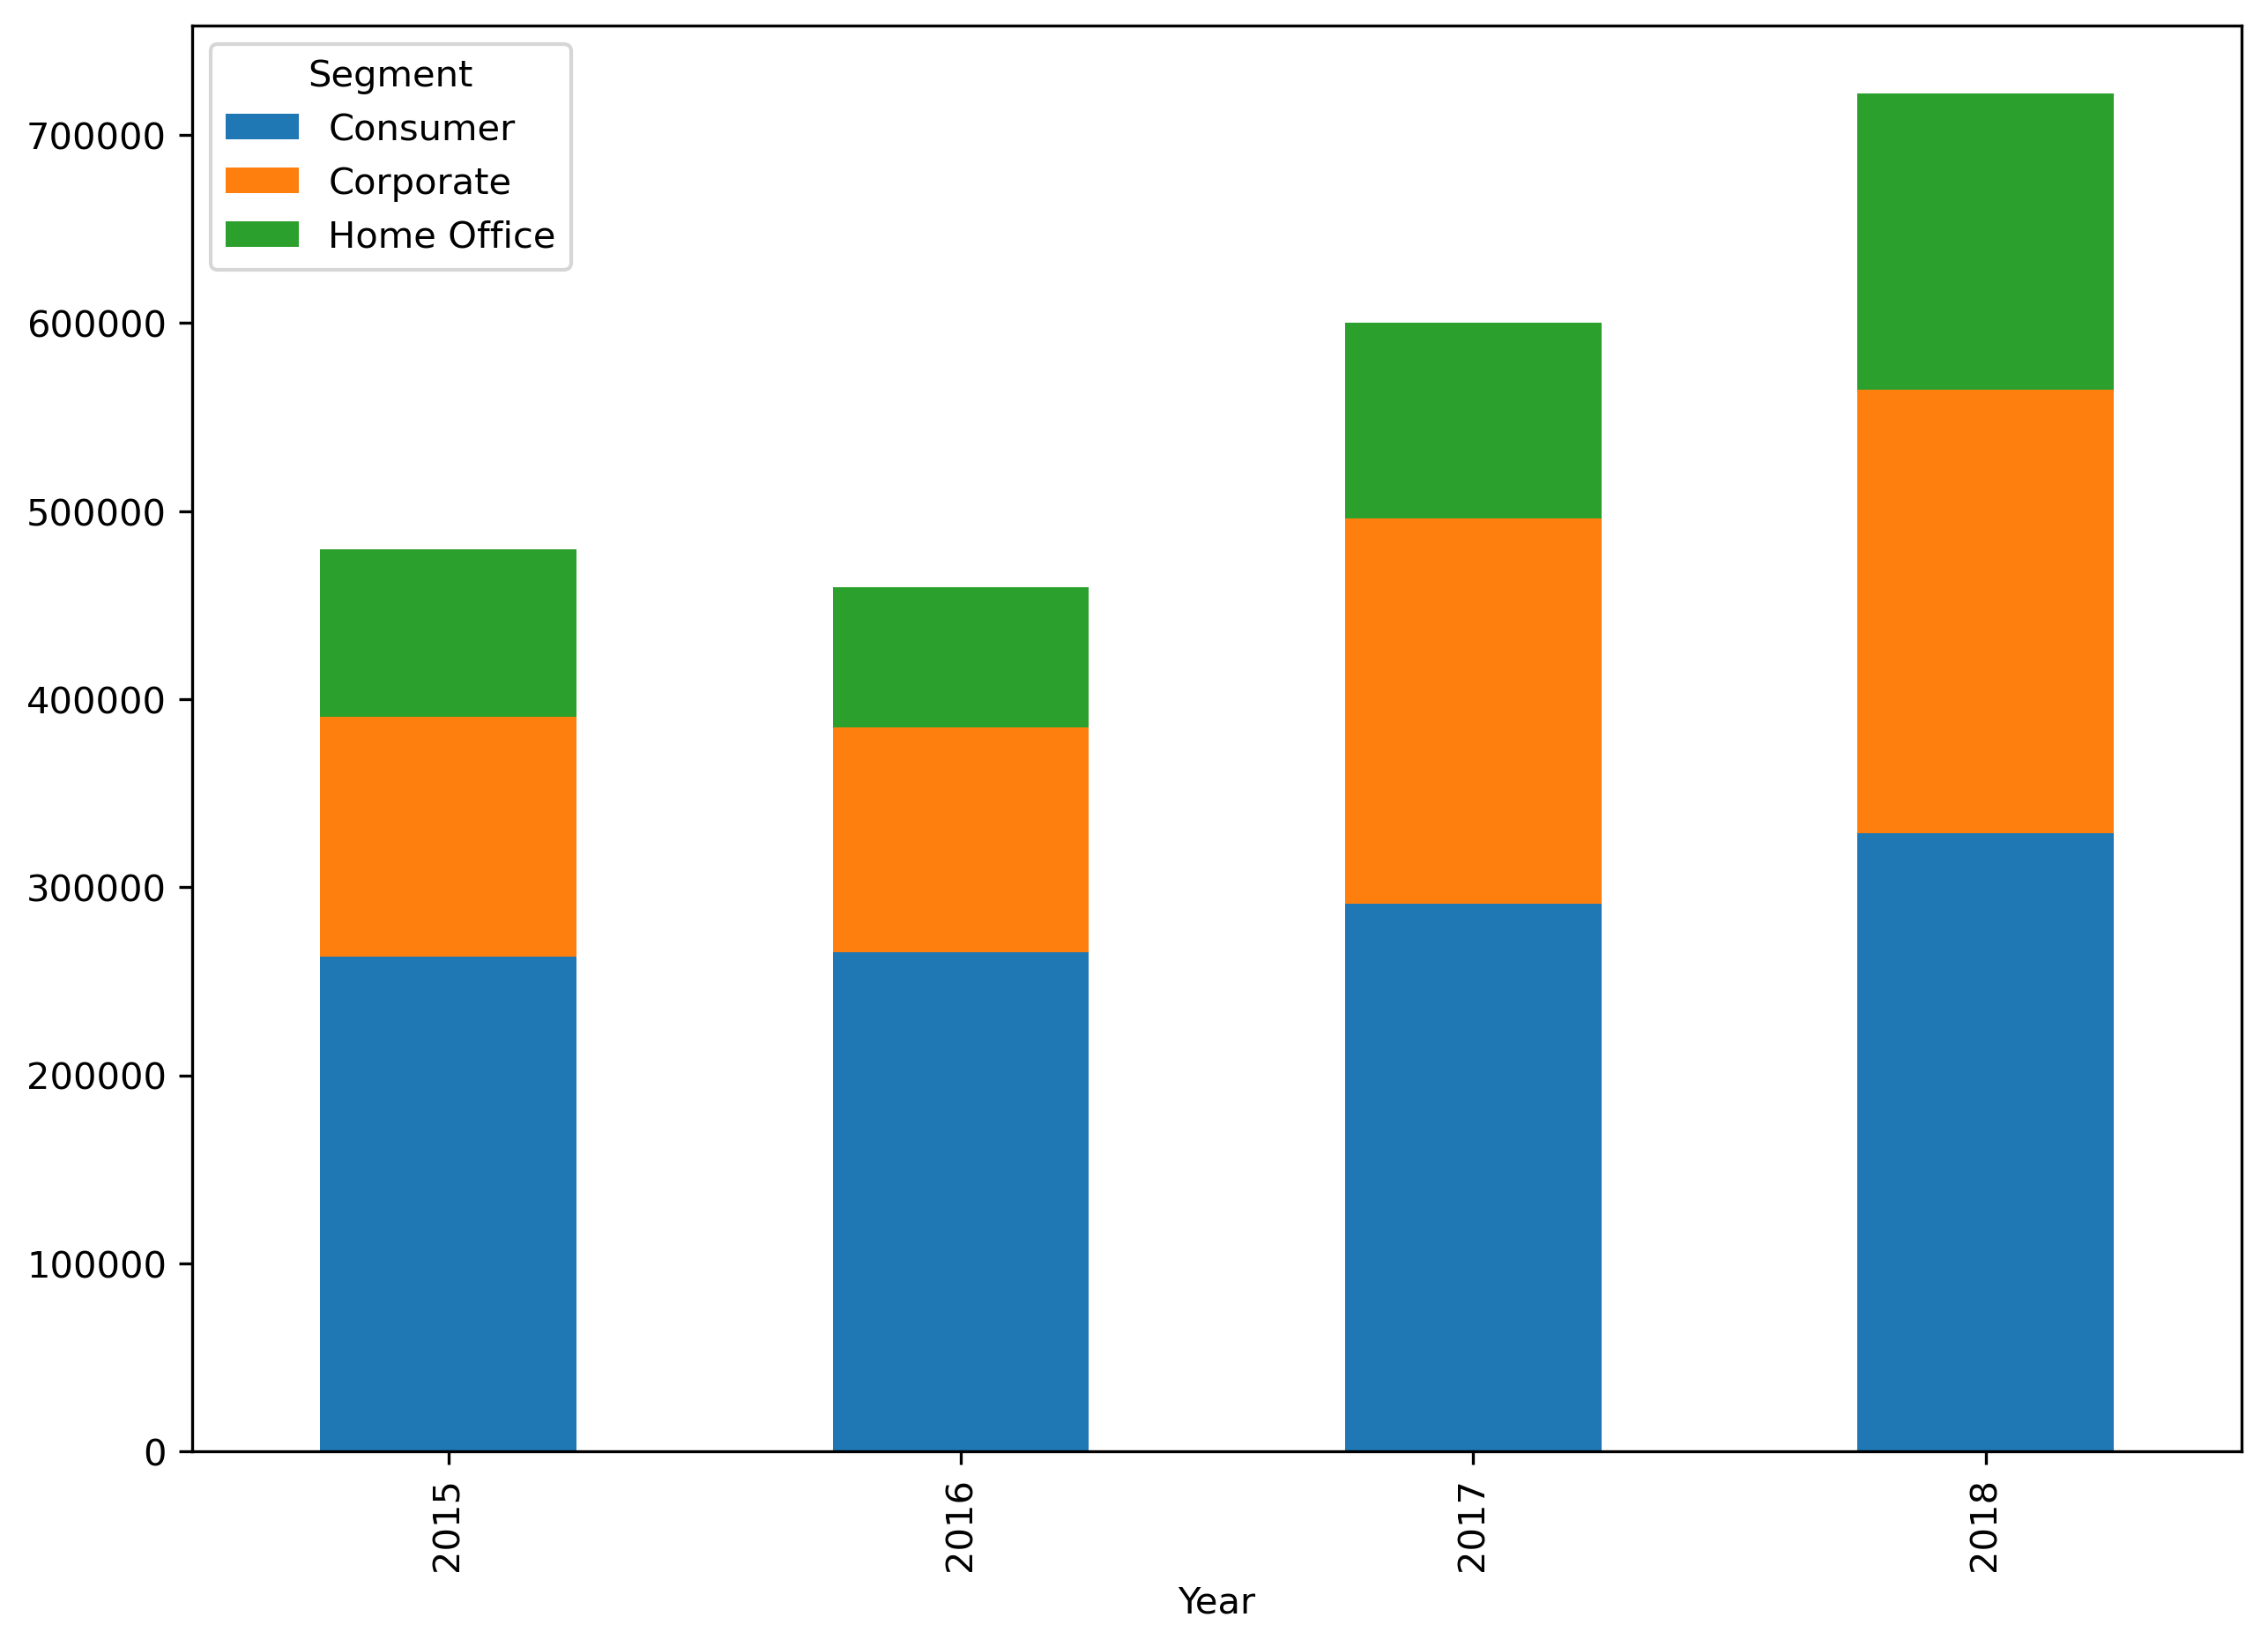

In [23]:
# 연도 별 고객 세그먼트 별 매출액 누적 막대 그래프 시각화
df_bar_2_pv.plot.bar(x='Year', stacked=True, figsize=(10,7))